In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('https://raw.githubusercontent.com/Sam-r-ai/CS580_Fall24_Justin_Cheung/refs/heads/assignment4/data.csv')



/home/jgcheung/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


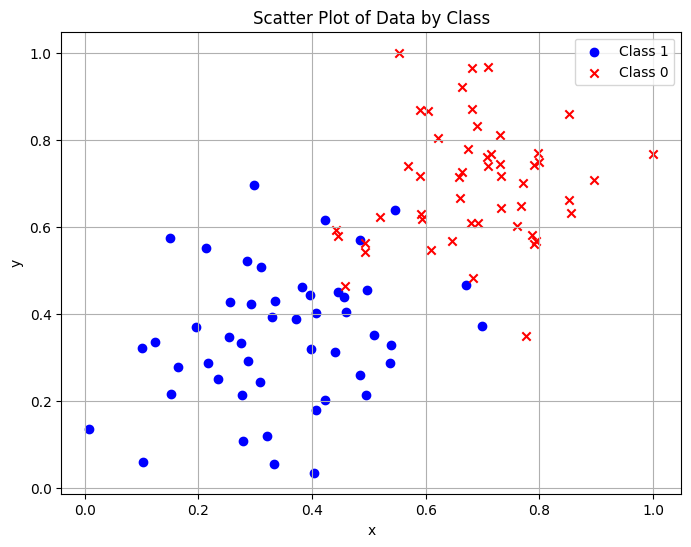

In [7]:
data.columns = ['x', 'y', 'label']

# Separate the data by label
class_1 = data[data['label'] == 1]
class_0 = data[data['label'] == 0]

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(class_1['x'], class_1['y'], color='blue', marker='o', label='Class 1')
plt.scatter(class_0['x'], class_0['y'], color='red', marker='x', label='Class 0')

# Label the plot
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of Data by Class')
plt.legend()
plt.grid(True)
plt.show()

Plotting vertical line at x = 0


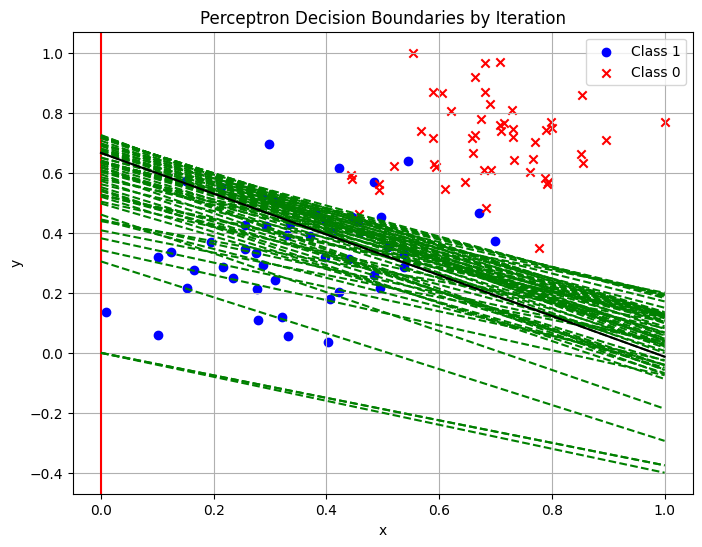

In [35]:
data.columns = ['x', 'y', 'label']
# Extract features and labels
X = data[['x', 'y']].values
y = data['label'].apply(lambda x: 1 if x == 1 else -1).values  # Convert labels to +1 and -1

# Initialize weights and bias
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 1  # This can be modified to observe the effect of different learning rates

# Function to plot decision boundary with vertical line handling
def plot_decision_boundary(weights, bias, color='black', linestyle='-'):
    # Check if weights[1] is close to zero to avoid division by zero
    if abs(weights[1]) < 1e-6:
        # Plot a vertical line for the decision boundary
        x_value = -bias / weights[0] if weights[0] != 0 else 0
        plt.axvline(x=x_value, color=color, linestyle=linestyle)
        print(f"Plotting vertical line at x = {x_value}")
    else:
        # Plot a regular decision boundary line
        x_values = np.linspace(0, 1, 100)  # Adjusted based on data range
        y_values = -(weights[0] * x_values + bias) / weights[1]
        plt.plot(x_values, y_values, color=color, linestyle=linestyle)

# Set up the plot
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', marker='o', label='Class 1')
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', marker='x', label='Class 0')

# Plot the initial decision boundary in red
plot_decision_boundary(weights, bias, color='red')

# Perceptron training loop
iterations = 65  # Number of iterations for demonstration
for iteration in range(iterations):
    errors = 0
    for i in range(len(y)):
        # Predict the class (1 if positive, -1 if negative)
        prediction = np.sign(np.dot(weights, X[i]) + bias)
        # Update weights and bias if there's a misclassification
        if prediction != y[i]:
            weights += learning_rate * y[i] * X[i]
            bias += learning_rate * y[i]
            errors += 1

    # Plot the separation line for this iteration in dashed green
    plot_decision_boundary(weights, bias, color='green', linestyle='--')

    # If no errors, training is complete
    if errors == 0:
        break

# Plot the final separation line in black
plot_decision_boundary(weights, bias, color='black')

# Label the plot
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Perceptron Decision Boundaries by Iteration")
plt.grid(True)
plt.show()

Skipping plot for undefined slope (vertical line).
Epoch 0, Log Loss: 0.6929889912792049
Epoch 10, Log Loss: 0.6914362140007113
Epoch 20, Log Loss: 0.6899336690770569
Epoch 30, Log Loss: 0.688477717779231
Epoch 40, Log Loss: 0.6870649949103128
Epoch 50, Log Loss: 0.6856923887407642
Epoch 60, Log Loss: 0.684357022314245
Epoch 70, Log Loss: 0.6830562360483209
Epoch 80, Log Loss: 0.6817875715553618
Epoch 90, Log Loss: 0.6805487566105689
Epoch 100, Log Loss: 0.6793376911961796
Epoch 110, Log Loss: 0.6781524345534722
Epoch 120, Log Loss: 0.6769911931769566
Epoch 130, Log Loss: 0.6758523096881456
Epoch 140, Log Loss: 0.674734252529394
Epoch 150, Log Loss: 0.6736356064214213
Epoch 160, Log Loss: 0.6725550635312886
Epoch 170, Log Loss: 0.6714914153006842
Epoch 180, Log Loss: 0.6704435448874174
Epoch 190, Log Loss: 0.6694104201759524
Epoch 200, Log Loss: 0.6683910873156435
Epoch 210, Log Loss: 0.667384664748058
Epoch 220, Log Loss: 0.6663903376873553
Epoch 230, Log Loss: 0.6654073530201488
Epoc

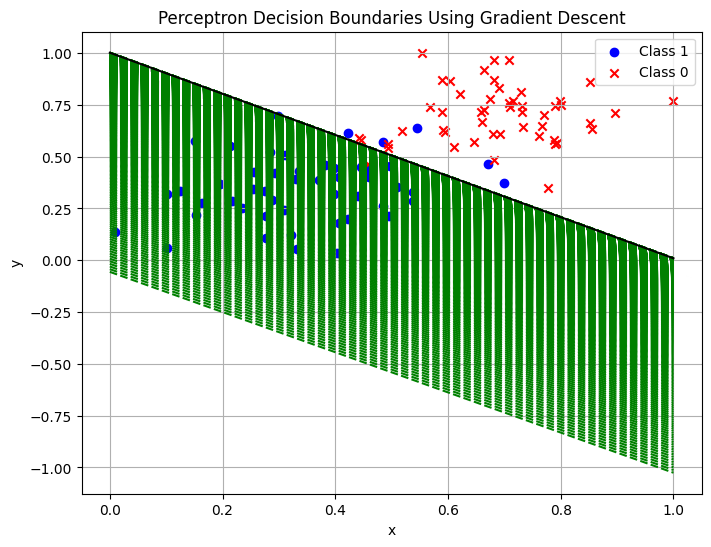

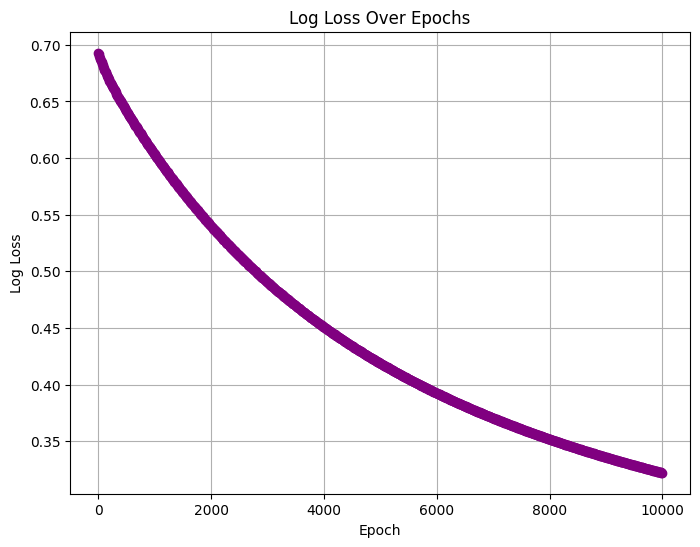

In [32]:
# Extract features and labels
X = data[['x', 'y']].values
y = data['label'].apply(lambda x: 1 if x == 1 else -1).values  # Convert labels to +1 and -1

# Initialize parameters
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.01  # You can experiment with different values here
epochs = 10000  # You can experiment with different values here
log_loss_values = []  # To store log loss values for plotting

# Function to calculate log loss (error)
def compute_log_loss(X, y, weights, bias):
    total_loss = 0
    for i in range(len(y)):
        linear_model = np.dot(X[i], weights) + bias
        # Sigmoid function to convert the output to a probability
        prob = 1 / (1 + np.exp(-y[i] * linear_model))
        # Log loss formula
        total_loss += np.log(1 + np.exp(-y[i] * linear_model))
    return total_loss / len(y)

# Function to plot decision boundary
def plot_decision_boundary(weights, bias, color='black', linestyle='-'):
    # Check if weights[1] is close to zero to avoid division by zero
    if abs(weights[1]) < 1e-6:
        print("Skipping plot for undefined slope (vertical line).")
        return
    
    x_values = np.linspace(0, 1, 100)  # Adjusted based on data range
    y_values = -(weights[0] * x_values + bias) / weights[1]
    plt.plot(x_values, y_values, color=color, linestyle=linestyle)


# Set up the plot for initial data
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', marker='o', label='Class 1')
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', marker='x', label='Class 0')

# Plot the initial decision boundary in red
plot_decision_boundary(weights, bias, color='red')

# Gradient Descent Training Loop
for epoch in range(epochs):
    # Initialize gradients for weights and bias
    weight_gradient = np.zeros(weights.shape)
    bias_gradient = 0

    # Compute gradients for all points
    for i in range(len(y)):
        linear_model = np.dot(X[i], weights) + bias
        probability = 1 / (1 + np.exp(-linear_model * y[i]))
        weight_gradient += (y[i] * X[i]) * (1 - probability)
        bias_gradient += y[i] * (1 - probability)

    # Update weights and bias using the gradients
    weights += learning_rate * weight_gradient / len(y)
    bias += learning_rate * bias_gradient / len(y)

    # Plot decision boundary every epoch
    if epoch % 10 == 0:
        plot_decision_boundary(weights, bias, color='green', linestyle='--')

    # Compute log loss every 10 epochs for plotting
    if epoch % 10 == 0:
        log_loss = compute_log_loss(X, y, weights, bias)
        log_loss_values.append(log_loss)
        print(f"Epoch {epoch}, Log Loss: {log_loss}")

# Plot the final decision boundary in black
plot_decision_boundary(weights, bias, color='black')

# Finalize the decision boundary plot
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Perceptron Decision Boundaries Using Gradient Descent")
plt.grid(True)
plt.show()

# Plot Log Loss over Epochs
plt.figure(figsize=(8, 6))
plt.plot(range(0, epochs, 10), log_loss_values, marker='o', color='purple')
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Log Loss Over Epochs")
plt.grid(True)
plt.show()